# 配套实践 07-01：二连杆正向运动学

本练习用平面二连杆理解关节角、末端位置和雅可比之间的关系，并用有限差分检查解析公式。依赖：NumPy、Matplotlib；CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/07-robot-state-and-action/" target="_blank">返回课程正文</a>

In [1]:
import numpy as np  # 计算关节运动学、雅可比和奇异值
import matplotlib.pyplot as plt  # 绘制机械臂轨迹与可达位置
plt.rcParams["figure.dpi"] = 120  # 提高笔记本图像显示清晰度

## 1. 从关节角计算末端位置

`forward_kinematics` 同时返回肘部和末端位置，方便把数值结果画成机械臂。角度统一使用弧度，长度统一使用米。

In [2]:
link_lengths = np.array([0.55, 0.40], dtype=np.float64)  # 定义两段连杆长度并统一使用米
def forward_kinematics(joint_angles):  # 定义平面二连杆正向运动学
    q1, q2 = joint_angles  # 读取基座关节和肘关节角度
    l1, l2 = link_lengths  # 读取两段连杆长度
    elbow = np.array([l1 * np.cos(q1), l1 * np.sin(q1)])  # 计算第一段末端也就是肘部位置
    end_effector = elbow + np.array([l2 * np.cos(q1 + q2), l2 * np.sin(q1 + q2)])  # 累加第二段得到末端位置
    return elbow, end_effector  # 返回两个关键点用于数值检查和绘图
joint_angles = np.deg2rad(np.array([35.0, -55.0]))  # 构造一组关节角并从度转换为弧度
elbow, end_effector = forward_kinematics(joint_angles)  # 计算当前构型的关节和末端位置
print("肘部位置: ", elbow.round(4), "m")  # 输出肘部米制坐标
print("末端位置: ", end_effector.round(4), "m")  # 输出末端米制坐标
assert np.linalg.norm(end_effector) <= link_lengths.sum() + 1e-9  # 验证末端没有超出最大可达半径

肘部位置:  [0.4505 0.3155] m
末端位置:  [0.8264 0.1787] m


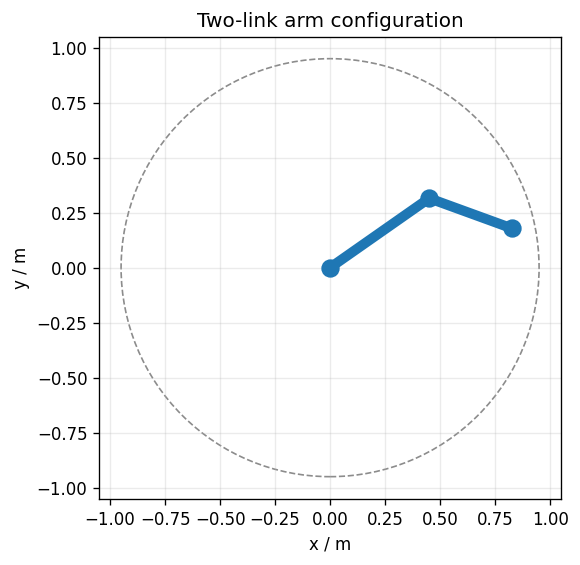

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))  # 创建显示机械臂构型的画布
points = np.vstack([np.zeros(2), elbow, end_effector])  # 拼接基座、肘部和末端三个点
ax.plot(points[:, 0], points[:, 1], "o-", linewidth=6, markersize=10)  # 用粗线连接机械臂关节
workspace = plt.Circle((0.0, 0.0), link_lengths.sum(), fill=False, linestyle="--", alpha=0.45)  # 创建最大可达圆边界
ax.add_patch(workspace)  # 把可达边界加入坐标轴
ax.set_aspect("equal")  # 使用相同横纵比例避免几何形状失真
ax.set_xlim(-1.05, 1.05)  # 固定水平显示范围
ax.set_ylim(-1.05, 1.05)  # 固定垂直显示范围
ax.set_xlabel("x / m")  # 标注水平坐标单位
ax.set_ylabel("y / m")  # 标注垂直坐标单位
ax.set_title("Two-link arm configuration")  # 添加无需中文字体的英文图题
ax.grid(alpha=0.25)  # 添加浅色网格便于读取坐标
plt.show()  # 显示当前机械臂构型

**怎样理解上一结果：** 数值输出给出当前关节角对应的肘部和末端米制位置，图中的虚线圆表示两段连杆完全伸直时的最大可达边界。当前末端位于边界内部，只说明位置可达；它没有检查碰撞、关节限位或末端朝向。

## 2. 用有限差分验证雅可比

解析雅可比应当预测很小关节变化造成的末端位移。若公式、关节顺序或角度单位写错，有限差分检查会立即暴露问题。

In [4]:
def jacobian(joint_angles):  # 定义二连杆末端位置对关节角的解析雅可比
    q1, q2 = joint_angles  # 读取两关节当前角度
    l1, l2 = link_lengths  # 读取连杆长度
    return np.array([[-l1 * np.sin(q1) - l2 * np.sin(q1 + q2), -l2 * np.sin(q1 + q2)], [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l2 * np.cos(q1 + q2)]])  # 返回二乘二速度映射矩阵
joint_velocity = np.array([0.25, -0.12])  # 定义当前关节速度并统一使用弧度每秒
predicted_velocity = jacobian(joint_angles) @ joint_velocity  # 使用雅可比预测末端瞬时速度
delta_time = 1e-5  # 设置足够小的有限差分时间间隔
_, future_position = forward_kinematics(joint_angles + joint_velocity * delta_time)  # 计算短时间后的末端位置
finite_difference = (future_position - end_effector) / delta_time  # 用位置差估计末端速度
error = np.linalg.norm(predicted_velocity - finite_difference)  # 计算解析速度与数值速度的差异
print("雅可比预测速度: ", predicted_velocity.round(5), "m/s")  # 输出解析速度
print("有限差分速度: ", finite_difference.round(5), "m/s")  # 输出数值速度
print(f"速度检查误差: {error:.3e} m/s")  # 报告两种结果的误差
assert error < 1e-5  # 确认雅可比公式与正向运动学一致

雅可比预测速度:  [-0.06108  0.1615 ] m/s
有限差分速度:  [-0.06108  0.1615 ] m/s
速度检查误差: 1.933e-07 m/s


**怎样理解上一结果：** 雅可比预测速度与有限差分速度几乎相同，说明当前解析公式、关节顺序和弧度单位一致。约 $10^{-7}$ 米每秒的残差来自有限差分近似和浮点误差；若误差很大，应先检查实现，而不是把它解释成机器人噪声。

## 3. 观察伸直构型附近的奇异性

当第二关节接近零、两段连杆几乎共线时，雅可比最小奇异值趋近零。此时某些末端方向难以通过有限关节速度实现。

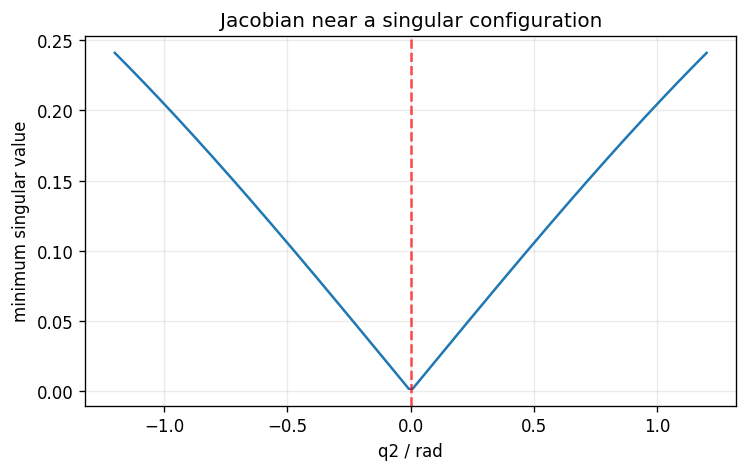

q2=0 时最小奇异值： 1.2964706709041047e-17


In [5]:
q2_values = np.linspace(-1.2, 1.2, 160)  # 扫描肘关节从弯曲到伸直再到反向弯曲
minimum_singular_values = []  # 创建列表记录每个构型的最小奇异值
for q2 in q2_values:  # 逐个检查不同肘关节角
    singular_values = np.linalg.svd(jacobian(np.array([0.4, q2])), compute_uv=False)  # 计算当前雅可比的奇异值
    minimum_singular_values.append(singular_values.min())  # 保存较小奇异值作为可控性指标
fig, ax = plt.subplots(figsize=(7, 4))  # 创建奇异值变化曲线画布
ax.plot(q2_values, minimum_singular_values)  # 绘制肘关节角与最小奇异值关系
ax.axvline(0.0, color="red", linestyle="--", alpha=0.7)  # 标出机械臂完全伸直的构型
ax.set_xlabel("q2 / rad")  # 标注肘关节角单位
ax.set_ylabel("minimum singular value")  # 标注纵轴指标
ax.set_title("Jacobian near a singular configuration")  # 添加英文图题
ax.grid(alpha=0.25)  # 添加浅色参考网格
plt.show()  # 显示奇异性曲线
print("q2=0 时最小奇异值：", np.linalg.svd(jacobian(np.array([0.4, 0.0])), compute_uv=False).min())  # 输出伸直构型的退化程度

**怎样理解结果：** 曲线在 $q_2=0$ 附近降到接近零，表示机械臂伸直时至少有一个末端运动方向失去有效控制能力。它不是“末端速度等于零”，而是某些期望末端速度需要异常大的关节速度，因此控制器应避免直接求逆或加入阻尼。

## 结论与练习

正向运动学把关节状态映射到末端位置，雅可比把关节速度映射到瞬时末端速度。尝试改变连杆长度或让第二关节更接近零，观察可达范围和最小奇异值怎样变化。